In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("retina")
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
df  = pd.read_csv("battery_dataset.csv")

In [4]:
df.head()

,352944080639365,samsung SM-A910F,8.0.0,Li-ion,5000.0,1570599938843,false,37,com.zopper.batteryage,0,24.7,3741,130,none,false.1,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,352944080639365,samsung SM-A910F,8.0.0,Li-ion,5000.0,1570599942514,False,37,com.zopper.batteryage,0,24.7,3763,130,none,False,NaN,NaN,NaN
1,352944080639365,samsung SM-A910F,8.0.0,Li-ion,5000.0,1570599942526,False,37,com.zopper.batteryage,0,24.7,3763,130,none,False,NaN,NaN,NaN
2,352944080639365,samsung SM-A910F,8.0.0,Li-ion,5000.0,1570599946877,False,37,com.zopper.batteryage,0,24.7,3763,130,none,False,NaN,NaN,NaN
3,352944080639365,samsung SM-A910F,8.0.0,Li-ion,5000.0,1570599947492,False,37,com.zopper.batteryage,0,24.7,3763,130,none,False,NaN,NaN,NaN
4,352944080639365,samsung SM-A910F,8.0.0,Li-ion,5000.0,1570599953460,False,37,com.zopper.batteryage,0,24.7,3763,130,none,False,NaN,NaN,NaN


In [5]:
df.columns

Index(['352944080639365', 'samsung SM-A910F', '8.0.0', 'Li-ion', '5000.0',
       '1570599938843', 'false', '37', 'com.zopper.batteryage', '0', '24.7',
       '3741', '130', 'none', 'false.1', 'Unnamed: 15', 'Unnamed: 16',
       'Unnamed: 17'],
      dtype='object')

Defining Columns Names

In [6]:
column_names = [
    "imei_number",
    "phone_model",
    "android_version",
    "battery_technology",
    "battery_capacity",
    "timestamp",  # will convert to IST after
    "screen_status",
    "battery_percentage",
    "app_running",
    "cpu_usage",
    "battery_temperature",
    "battery_voltage",
    "battery_current",
    "network_connected",
    "plugged_in",
]
df = pd.read_csv("battery_dataset.csv", header=None, names=column_names, skiprows=1)

In [7]:
df.columns

Index(['imei_number', 'phone_model', 'android_version', 'battery_technology',
       'battery_capacity', 'timestamp', 'screen_status', 'battery_percentage',
       'app_running', 'cpu_usage', 'battery_temperature', 'battery_voltage',
       'battery_current', 'network_connected', 'plugged_in'],
      dtype='object')

In [8]:

print(df.isnull().sum())


print((df.isnull().mean() * 100).round(2).sort_values(ascending=False))

imei_number                 0
phone_model                 0
android_version             0
battery_technology          0
battery_capacity            0
timestamp                   0
screen_status               0
battery_percentage          0
app_running                 0
cpu_usage                   0
battery_temperature         0
battery_voltage             0
battery_current        385429
network_connected      385429
plugged_in             385429
dtype: int64
battery_current        100.0
plugged_in             100.0
network_connected      100.0
battery_technology       0.0
imei_number              0.0
phone_model              0.0
android_version          0.0
screen_status            0.0
timestamp                0.0
battery_capacity         0.0
battery_percentage       0.0
battery_temperature      0.0
cpu_usage                0.0
app_running              0.0
battery_voltage          0.0
dtype: float64


In [9]:
print(df.dtypes)

imei_number             object
phone_model            float64
android_version          int64
battery_technology        bool
battery_capacity         int64
timestamp               object
screen_status            int64
battery_percentage     float64
app_running              int64
cpu_usage                int64
battery_temperature     object
battery_voltage           bool
battery_current        float64
network_connected      float64
plugged_in             float64
dtype: object


In [10]:
print(df.head(5).to_string())

                                       imei_number  phone_model  android_version  battery_technology  battery_capacity              timestamp  screen_status  battery_percentage  app_running  cpu_usage battery_temperature  battery_voltage  battery_current  network_connected  plugged_in
352944080639365 samsung SM-A910F 8.0.0      Li-ion       5000.0    1570599942514               False                37  com.zopper.batteryage              0                24.7         3763        130                none            False              NaN                NaN         NaN
                                 8.0.0      Li-ion       5000.0    1570599942526               False                37  com.zopper.batteryage              0                24.7         3763        130                none            False              NaN                NaN         NaN
                                 8.0.0      Li-ion       5000.0    1570599946877               False                37  com.zopper.batteryage 

In [11]:
df = df.dropna(subset=["imei_number"])

In [12]:
print(df["imei_number"].isnull().sum())
print(df["imei_number"].nunique())
print(df.shape[0])

0
1
385429


In [13]:
df["battery_capacity"] = pd.to_numeric(df["battery_capacity"], errors="coerce")
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
df["battery_percentage"] = pd.to_numeric(df["battery_percentage"], errors="coerce")
df["cpu_usage"] = pd.to_numeric(df["cpu_usage"], errors="coerce")
df["battery_temperature"] = pd.to_numeric(df["battery_temperature"], errors="coerce")
df["battery_voltage"] = pd.to_numeric(df["battery_voltage"], errors="coerce")
df["battery_current"] = pd.to_numeric(df["battery_current"], errors="coerce")
df["network_connected"] = df["network_connected"].astype(
    str
)  # if values are like "WiFi", "LTE"
df["plugged_in"] = (
    df["plugged_in"].astype(str).str.lower().map({"true": True, "false": False})
)
df["screen_status"] = (
    df["screen_status"].astype(str).str.lower().map({"true": True, "false": False})
)

Convert UNIX epoch to datetime in IST

In [14]:
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True).dt.tz_convert(
    "Asia/Karachi"
)

In [15]:
print(df.dtypes)
print(df[["timestamp", "battery_percentage", "battery_current", "cpu_usage"]].head())

imei_number                                  object
phone_model                                 float64
android_version                               int64
battery_technology                             bool
battery_capacity                              int64
timestamp              datetime64[ns, Asia/Karachi]
screen_status                                object
battery_percentage                          float64
app_running                                   int64
cpu_usage                                     int64
battery_temperature                         float64
battery_voltage                                bool
battery_current                             float64
network_connected                            object
plugged_in                                   object
dtype: object
                                       timestamp  battery_percentage  \
352944080639365 samsung SM-A910F 8.0.0       NaT                24.7   
                                 8.0.0       NaT              

In [16]:
print((df.isnull().mean() * 100).round(2).sort_values(ascending=False))

screen_status          100.0
timestamp              100.0
battery_temperature    100.0
battery_current        100.0
plugged_in             100.0
android_version          0.0
imei_number              0.0
battery_technology       0.0
battery_capacity         0.0
phone_model              0.0
battery_percentage       0.0
cpu_usage                0.0
app_running              0.0
battery_voltage          0.0
network_connected        0.0
dtype: float64


In [17]:
df = df.drop(columns=df.columns[df.isnull().all()])

In [18]:
print(df.columns)

Index(['imei_number', 'phone_model', 'android_version', 'battery_technology',
       'battery_capacity', 'battery_percentage', 'app_running', 'cpu_usage',
       'battery_voltage', 'network_connected'],
      dtype='object')


 CPU Usage vs Battery Percentage

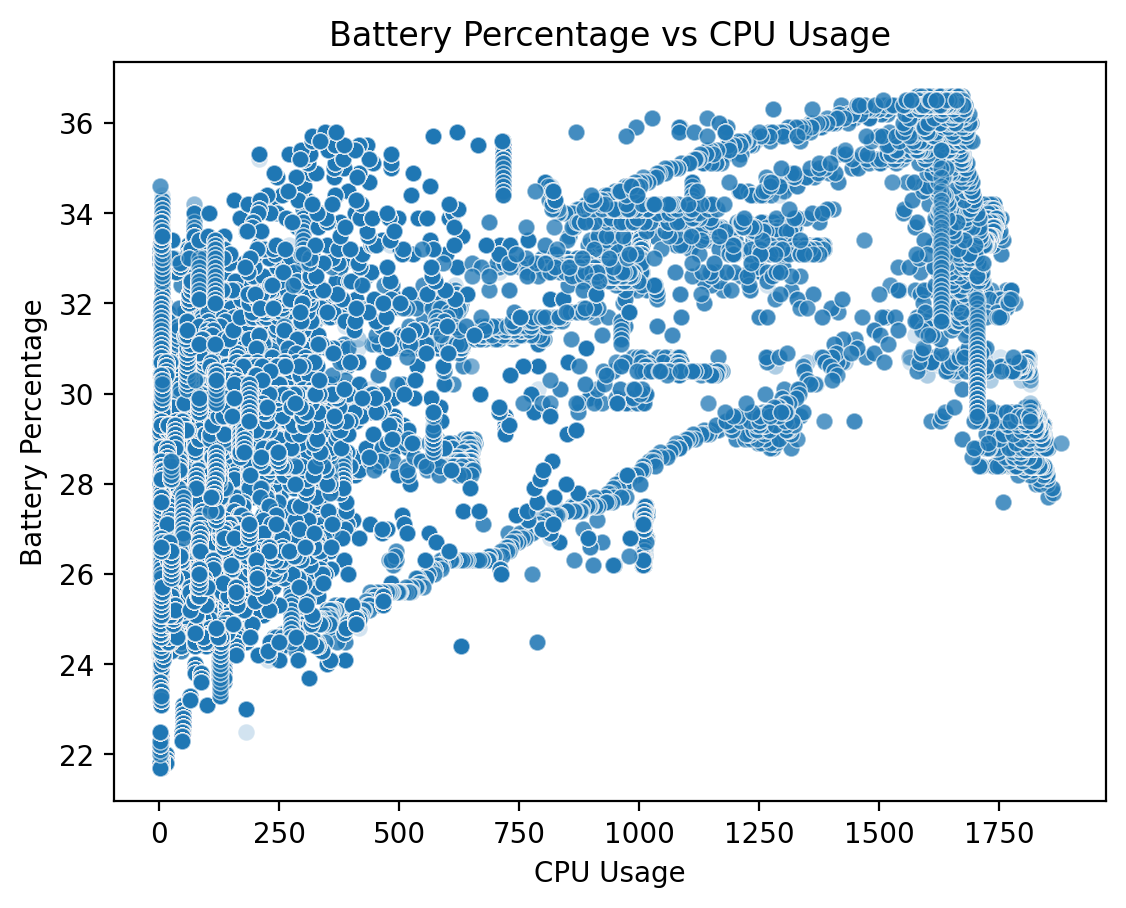

In [19]:
sns.scatterplot(data=df, x="cpu_usage", y="battery_percentage", alpha=0.2)
plt.title("Battery Percentage vs CPU Usage")
plt.xlabel("CPU Usage")
plt.ylabel("Battery Percentage")
plt.show()


Explore App Usage Impact

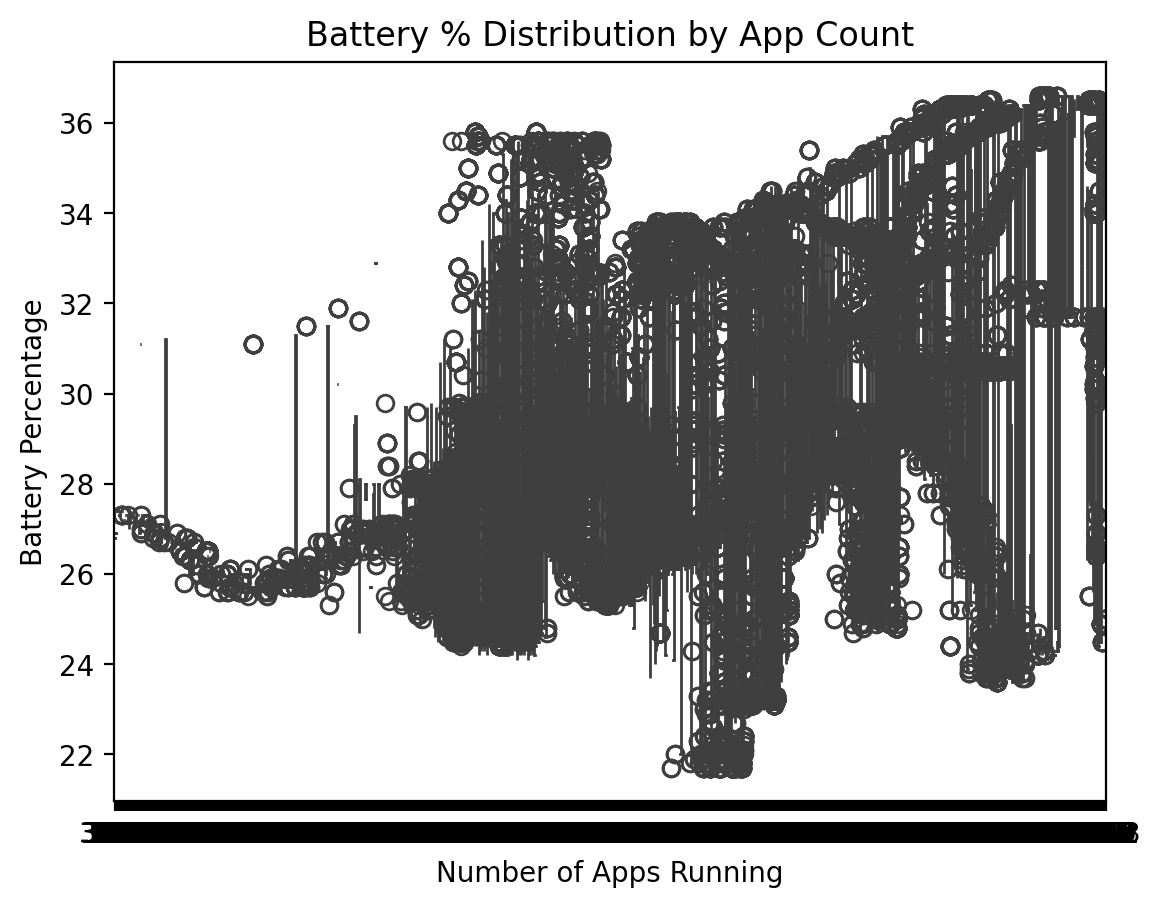

In [20]:
sns.boxplot(data=df, x="app_running", y="battery_percentage")
plt.title("Battery % Distribution by App Count")
plt.xlabel("Number of Apps Running")
plt.ylabel("Battery Percentage")
plt.show()

Correlation Matrix

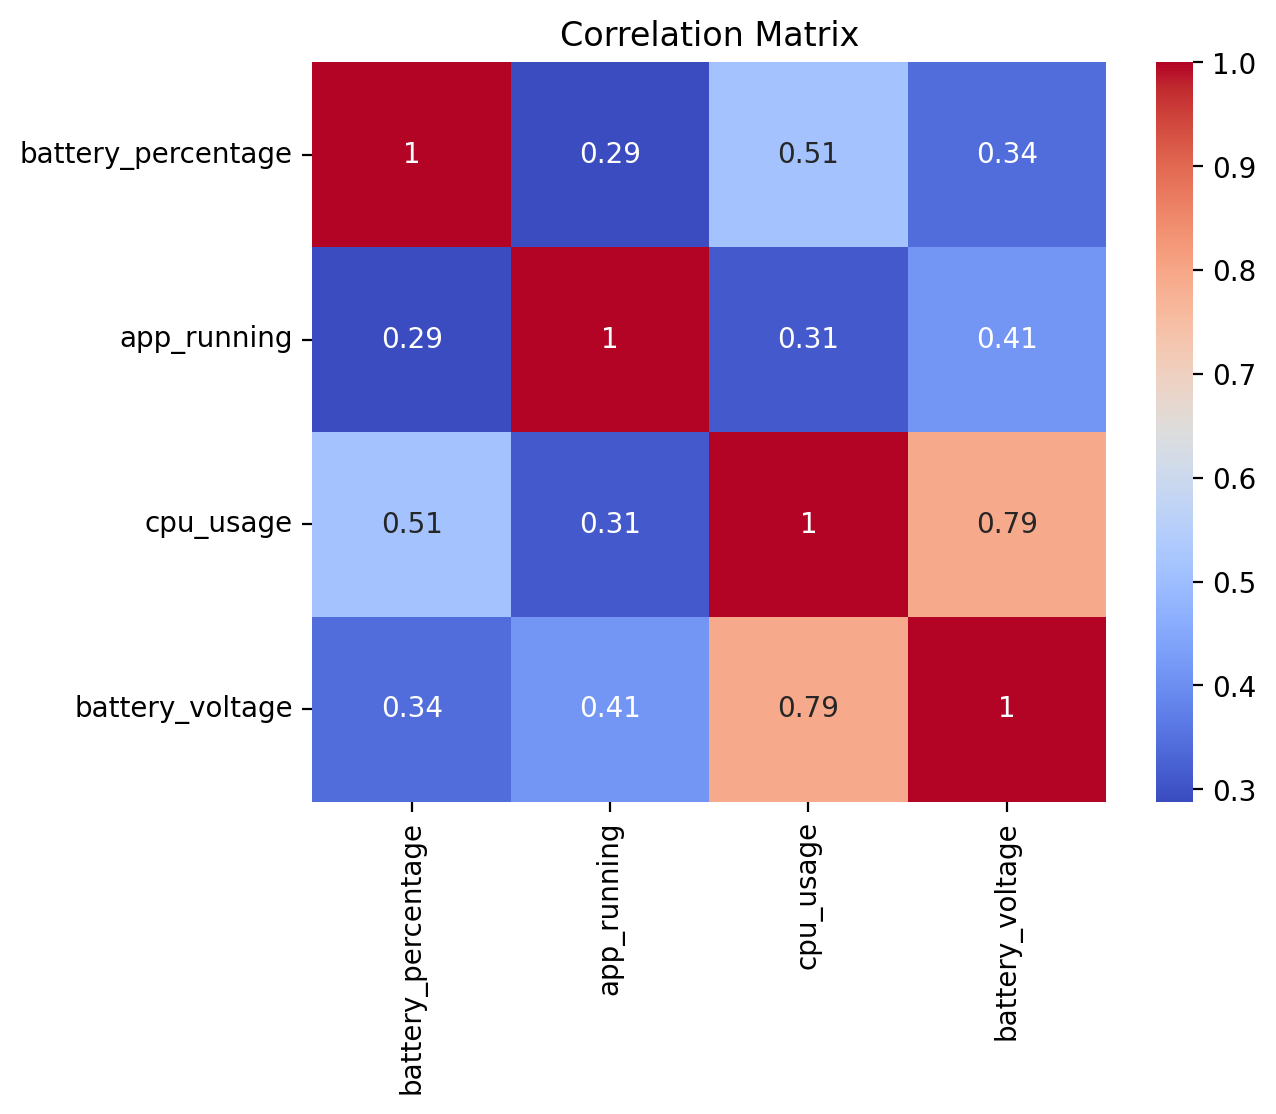

In [21]:
corr = df[["battery_percentage", "app_running", "cpu_usage", "battery_voltage"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

 Try Clustering to Detect Battery Usage Patterns

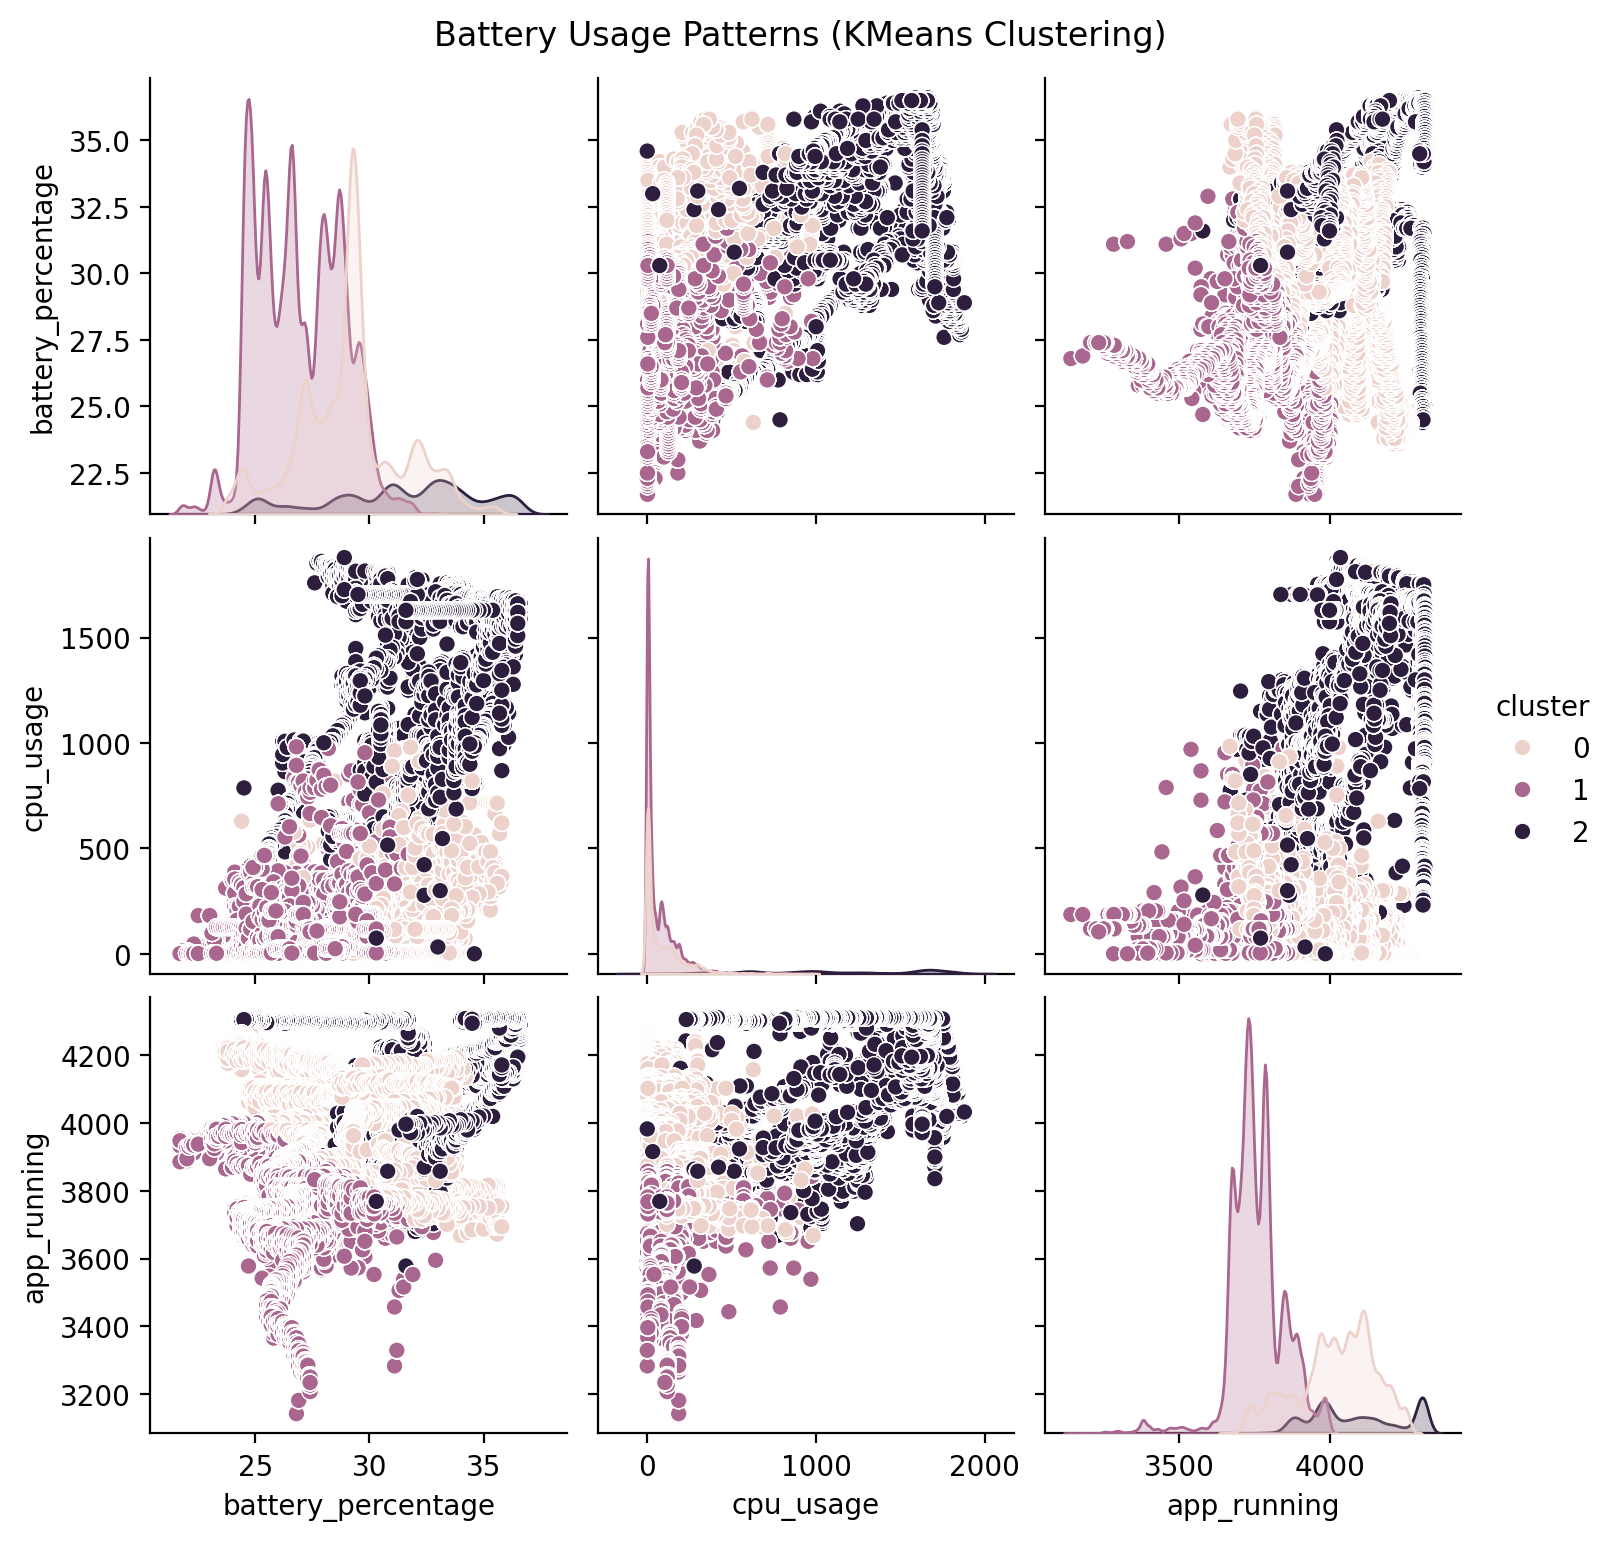

In [22]:
features = df[["battery_percentage", "app_running", "cpu_usage", "battery_voltage"]]
scaled = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(scaled)

sns.pairplot(df, vars=["battery_percentage", "cpu_usage", "app_running"], hue="cluster")
plt.suptitle("Battery Usage Patterns (KMeans Clustering)", y=1.02)
plt.show()

In [23]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

##### LSTM Model Training

In [25]:
numeric_cols = ["battery_percentage", "app_running", "cpu_usage", "battery_voltage"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

if df.empty:
    print(
        "DataFrame is empty after preprocessing. Please check your data source and preprocessing steps."
    )
else:
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(df[numeric_cols])

    def create_sequences(data, seq_length):
        X, y = [], []
        for i in range(len(data) - seq_length):
            X.append(data[i : i + seq_length])
            y.append(data[i + seq_length, 0])
        return np.array(X), np.array(y)

    seq_length = 24
    X, y = create_sequences(scaled_data, seq_length)

    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    model = Sequential()
    model.add(
        LSTM(
            50,
            activation="relu",
            return_sequences=False,
            input_shape=(seq_length, len(numeric_cols)),
        )
    )
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse")
    history = model.fit(
        X_train, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=1
    )

c:\Users\mabd0\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
8672/8672 ━━━━━━━━━━━━━━━━━━━━ 84s 9ms/step - loss: 0.0016 - val_loss: 6.3267e-06
Epoch 2/30
8672/8672 ━━━━━━━━━━━━━━━━━━━━ 66s 8ms/step - loss: 5.6337e-06 - val_loss: 9.3310e-06
Epoch 3/30
8672/8672 ━━━━━━━━━━━━━━━━━━━━ 66s 8ms/step - loss: 4.1644e-06 - val_loss: 7.3986e-07
Epoch 4/30
8672/8672 ━━━━━━━━━━━━━━━━━━━━ 67s 8ms/step - loss: 3.1120e-06 - val_loss: 1.1065e-06
Epoch 5/30
8672/8672 ━━━━━━━━━━━━━━━━━━━━ 78s 9ms/step - loss: 2.9271e-06 - val_loss: 1.0925e-06
Epoch 6/30
8672/8672 ━━━━━━━━━━━━━━━━━━━━ 77s 9ms/step - loss: 2.7598e-06 - val_loss: 9.1230e-07
Epoch 7/30
8672/8672 ━━━━━━━━━━━━━━━━━━━━ 76s 9ms/step - loss: 2.5887e-06 - val_loss: 7.7121e-07
Epoch 8/30
8672/8672 ━━━━━━━━━━━━━━━━━━━━ 76s 9ms/step - loss: 2.3166e-06 - val_loss: 5.7863e-07
Epoch 9/30
8672/8672 ━━━━━━━━━━━━━━━━━━━━ 77s 9ms/step - loss: 2.1073e-06 - val_loss: 5.4503e-07
Epoch 10/30
8672/8672 ━━━━━━━━━━━━━━━━━━━━ 77s 9ms/step - loss: 2.2483e-06 - val_loss: 6.1686e-07
Epoch 11/30
8672/8672 ━━━━━━━━━━━

##### Plot training history

In [26]:
model.save("battery_lstm_model.h5")
print("Model saved as battery_lstm_model.h5")

Model saved as battery_lstm_model.h5


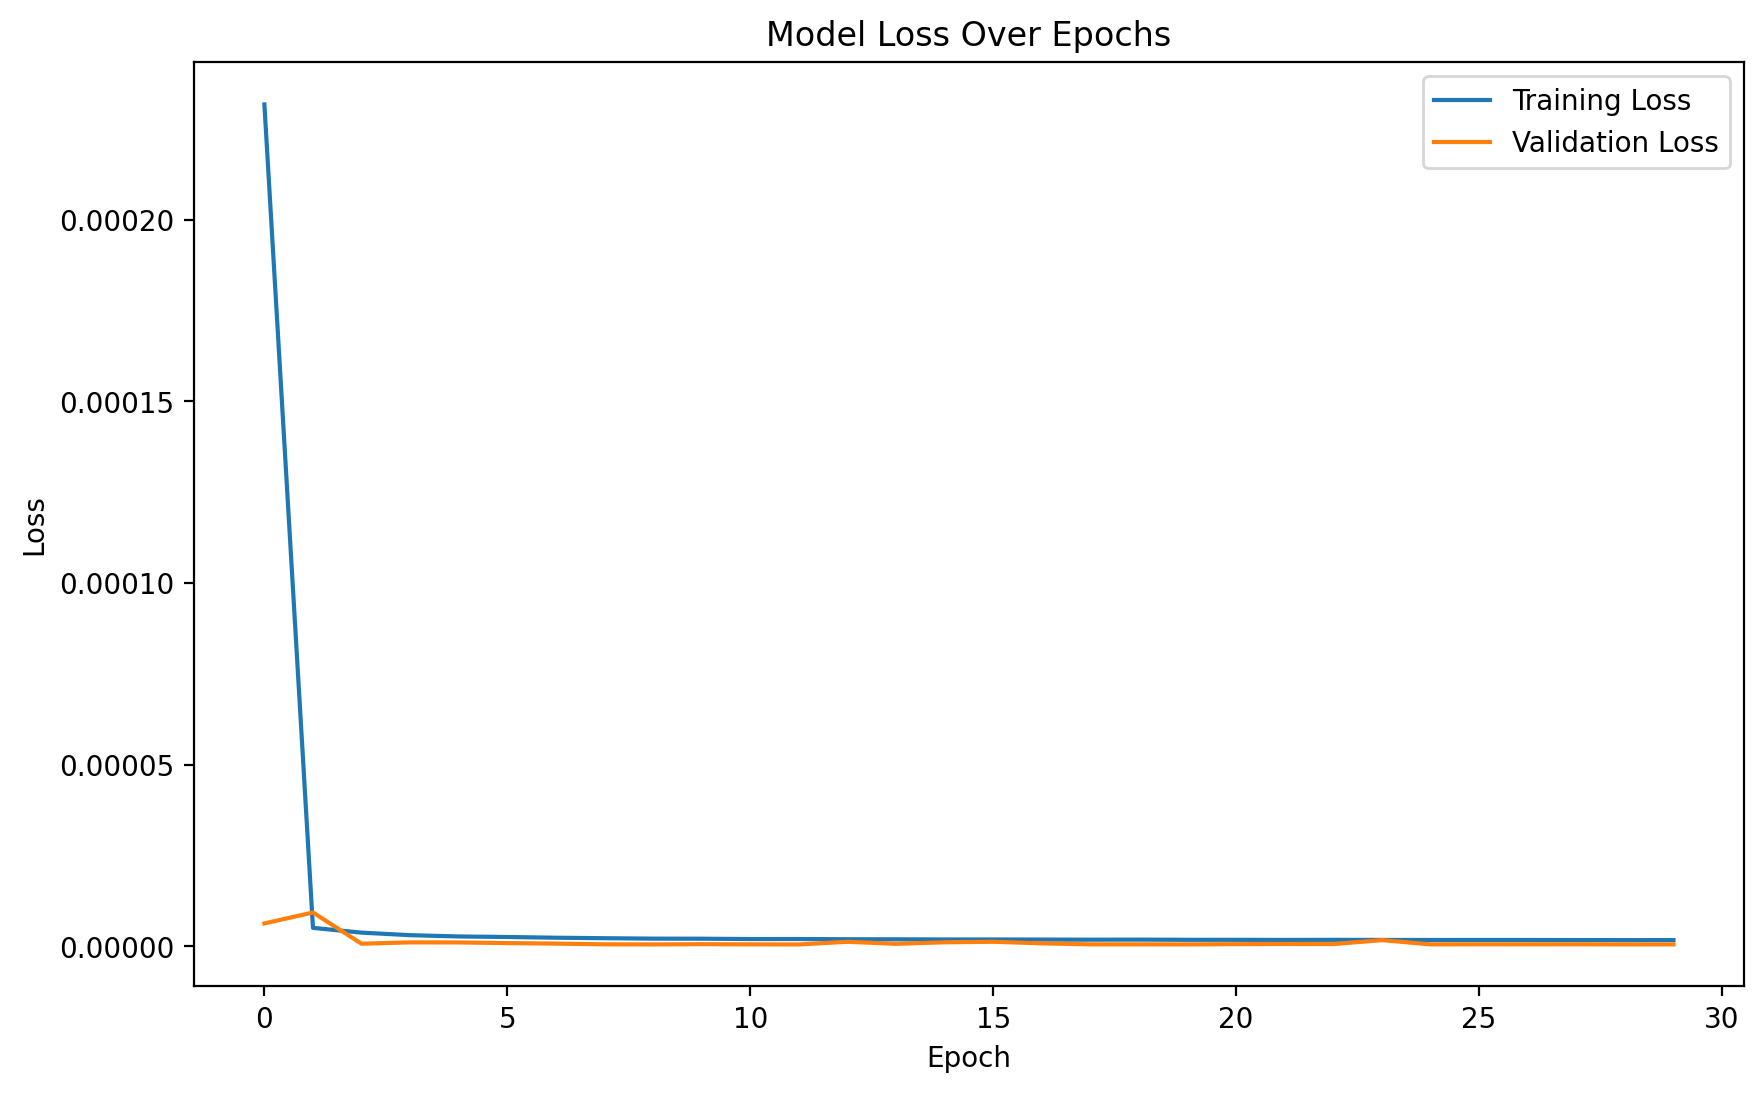

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Test Loss (MSE): 0.0000
2409/2409 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


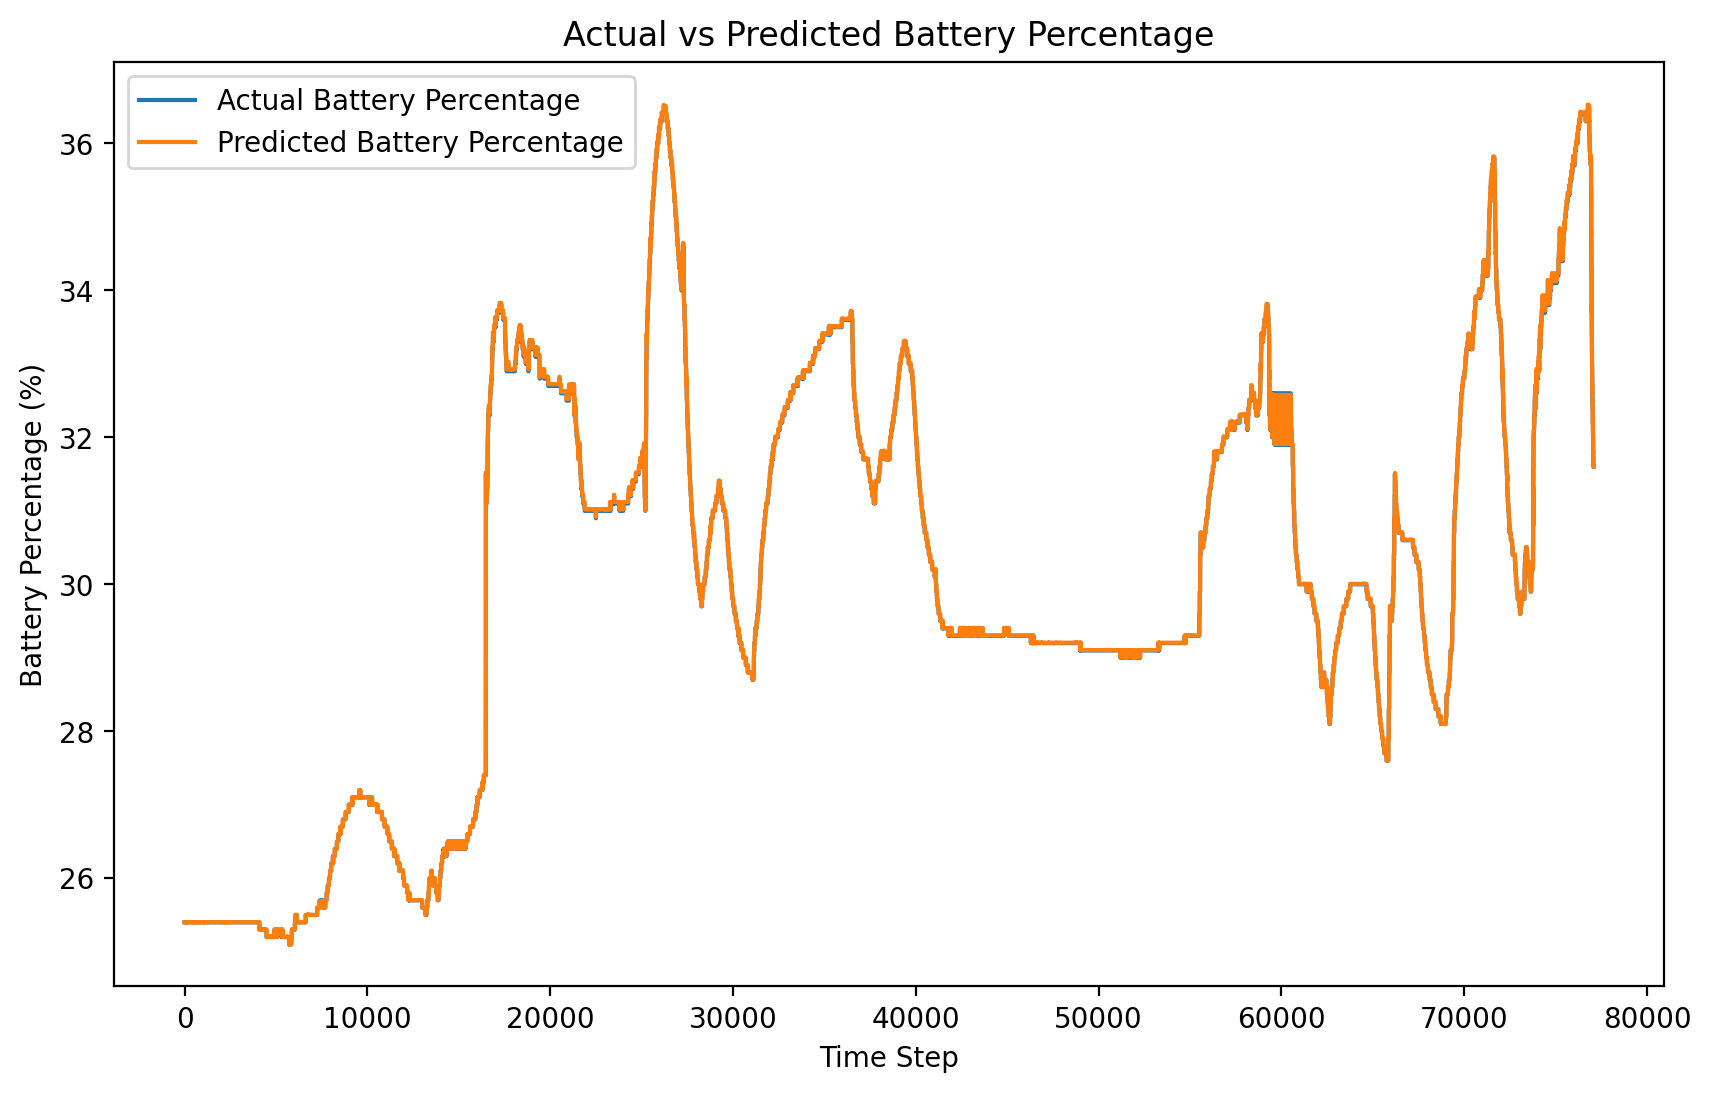

In [28]:
loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (MSE): {loss:.4f}")

y_pred = model.predict(X_test)
y_test_inv = scaler.inverse_transform(
    np.concatenate((y_test.reshape(-1, 1), np.zeros((len(y_test), 3))), axis=1)
)[:, 0]
y_pred_inv = scaler.inverse_transform(
    np.concatenate((y_pred, np.zeros((len(y_pred), 3))), axis=1)
)[:, 0]

plt.figure(figsize=(10, 6))
plt.plot(y_test_inv, label="Actual Battery Percentage")
plt.plot(y_pred_inv, label="Predicted Battery Percentage")
plt.title("Actual vs Predicted Battery Percentage")
plt.xlabel("Time Step")
plt.ylabel("Battery Percentage (%)")
plt.legend()
plt.show()



#####  Forecast future values

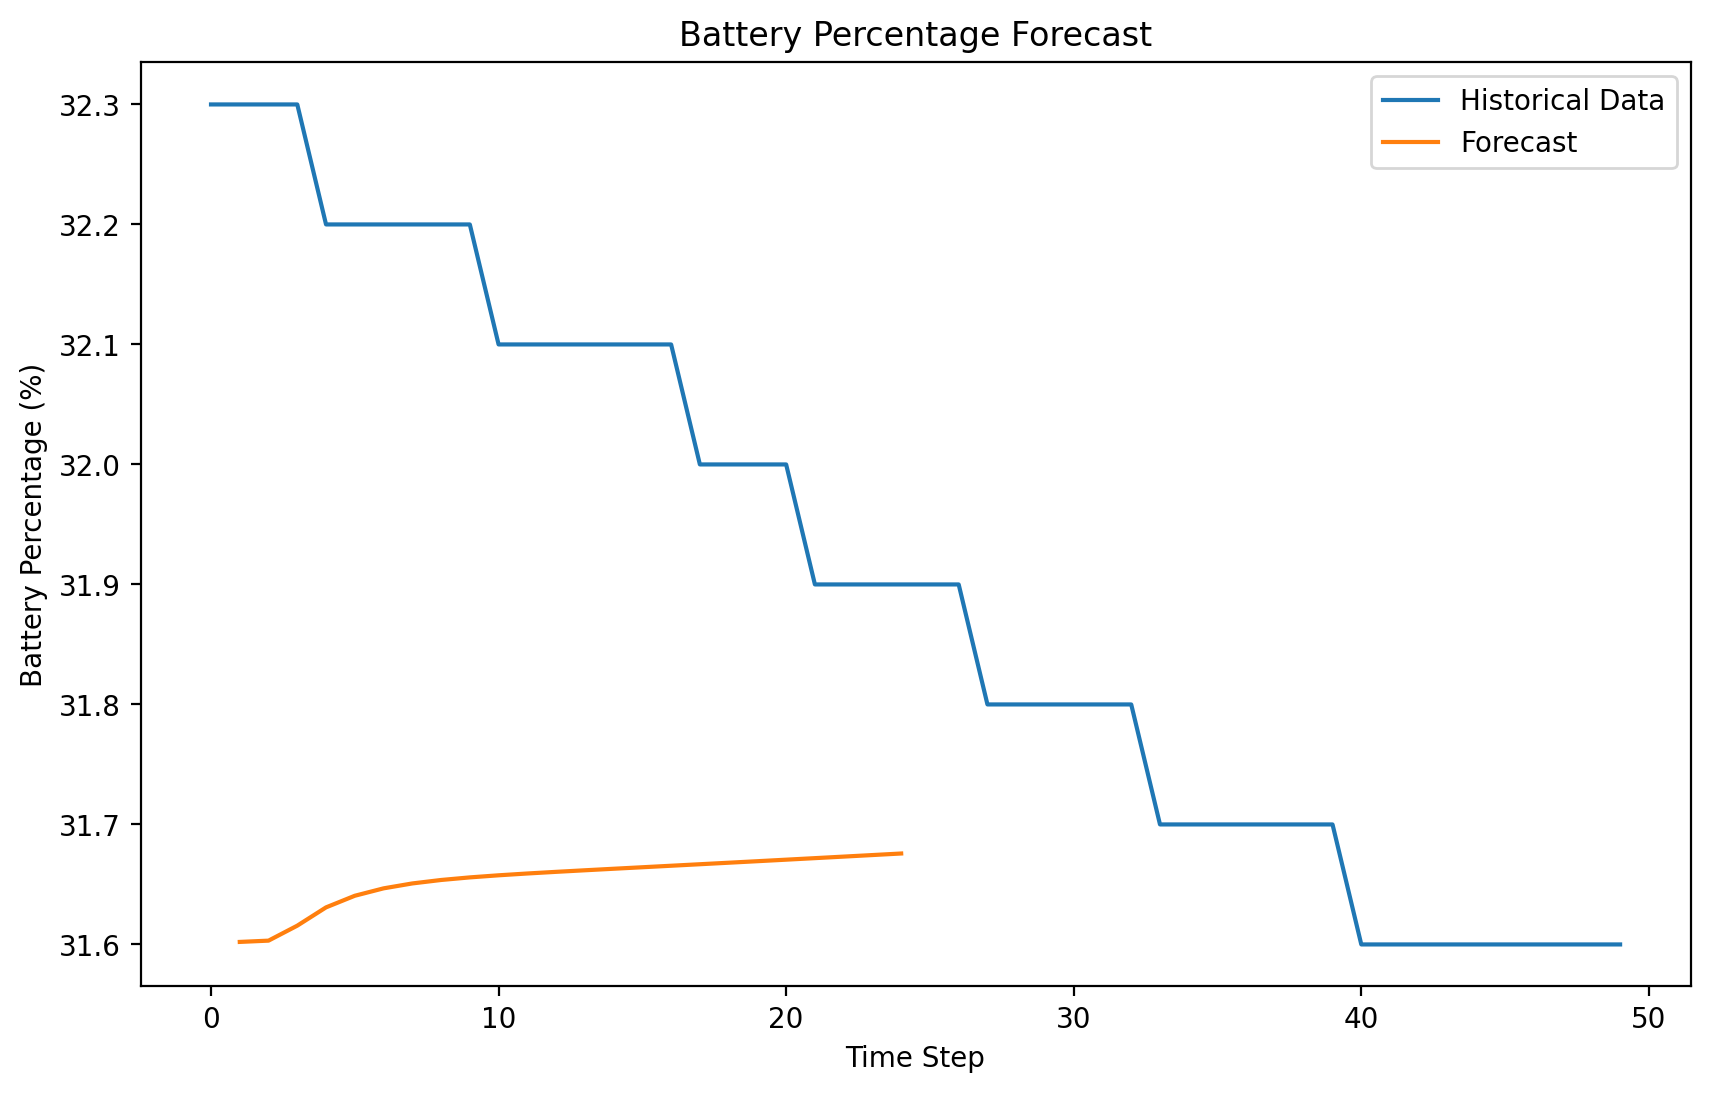

In [29]:

last_sequence = scaled_data[-seq_length:]
future_predictions = []
current_sequence = last_sequence.copy()

for _ in range(24):
    next_pred = model.predict(
        current_sequence.reshape(1, seq_length, len(numeric_cols)), verbose=0
    )
    future_predictions.append(next_pred[0, 0])
    current_sequence = np.roll(current_sequence, -1, axis=0)
    current_sequence[-1] = np.concatenate((next_pred, np.zeros((1, 3))), axis=1)[0]

future_predictions_inv = scaler.inverse_transform(
    np.concatenate(
        (np.array(future_predictions).reshape(-1, 1), np.zeros((24, 3))), axis=1
    )
)[:, 0]


plt.figure(figsize=(10, 6))
plt.plot(
    np.arange(len(scaled_data[-50:])),
    scaler.inverse_transform(scaled_data[-50:])[:, 0],
    label="Historical Data",
)
plt.plot(
    np.arange(len(scaled_data[-1:]), len(scaled_data[-1:]) + 24),
    future_predictions_inv,
    label="Forecast",
)
plt.title("Battery Percentage Forecast")
plt.xlabel("Time Step")
plt.ylabel("Battery Percentage (%)")
plt.legend()
plt.show()